In [1]:
import pandas as pd

In [2]:
features = pd.read_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/features_ComBat_per_feature.csv')


In [3]:
print(features)

     Subject    Group    Center    FIQ     IQ  Whole_Energy_global  \
0      50499      ASD       USM  113.0  113.0          -290.682717   
1      50694      ASD  LEUVEN_1  109.0  109.0          -318.876937   
2      51020      ASD       NYU  107.0  107.0          -153.673174   
3      51470      ASD   CALTECH  124.0  124.0          -214.630270   
4      50518      ASD       USM   77.0   77.0          -316.207670   
..       ...      ...       ...    ...    ...                  ...   
177    50467  Control       USM   89.0   89.0          -297.382174   
178    50433  Control       USM  100.0  100.0          -205.622952   
179    50463  Control       USM  121.0  121.0          -155.117375   
180    51342  Control   MAX_MUN  107.0  107.0          -165.340792   
181    51066  Control       NYU  112.0  112.0          -204.936567   

     Whole_Prop_agreement  Whole_Prop_disagreement  \
0                0.250705                 0.270537   
1                0.253207                 0.273273 

STRATIFIED STATISTICAL COMPARISON: ASD vs Control (by Feature Level)

CATEGORY: WHOLE (n=6 features)

Total features tested: 6
Significant features (uncorrected p < 0.05): 5
Significant features (FDR-corrected p < 0.05): 5

SIGNIFICANT FEATURES - WHOLE (UNCORRECTED p < 0.05):
                   Feature    ASD_Mean  Control_Mean      Test_Used  p_value
       Whole_Energy_global -264.922086   -210.852402 Mann-Whitney U 0.000835
      Whole_Prop_agreement    0.250233      0.247501 Mann-Whitney U 0.000974
Whole_Prop_imbalanced_same    0.247267      0.250015 Mann-Whitney U 0.000925
   Whole_Prop_disagreement    0.269487      0.267287         t-test 0.007788
 Whole_Prop_imbalanced_opp    0.233014      0.235195         t-test 0.008351

----------------------------------------------------------------------------------------------------

SIGNIFICANT FEATURES - WHOLE (FDR-CORRECTED p < 0.05):
                   Feature    ASD_Mean  Control_Mean      Test_Used  p_corrected
       Whole_Energy_gl

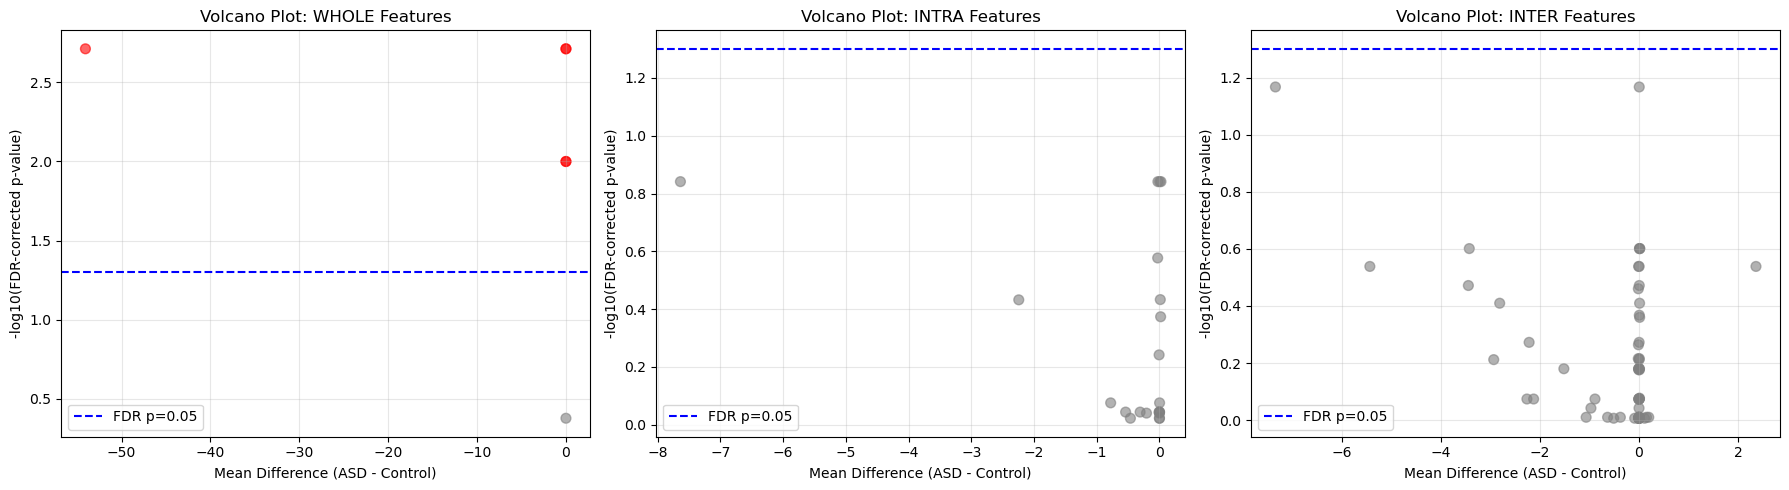


Volcano plots (stratified by level) saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/volcano_plot_stratified_by_level.png'


In [16]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exclude non-feature columns
exclude_cols = {'Subject', 'Group', 'Center' ,'FIQ', 'IQ'}
feature_cols = [col for col in features.columns if col not in exclude_cols]

# Categorize features by prefix (Whole_, Intra_, Inter_)
def get_feature_category(col_name):
    """Extract category from feature name"""
    if col_name.startswith('Inter_'):
        return 'Inter'
    elif col_name.startswith('Intra_'):
        return 'Intra'
    elif col_name.startswith('Whole_'):
        return 'Whole'
    else:
        return 'Unknown'

# Separate data by group
asd_data = features[features['Group'] == 'ASD'][feature_cols]
control_data = features[features['Group'] == 'Control'][feature_cols]

# Process each category separately
all_results = []
categories = ['Whole', 'Intra', 'Inter']

print("=" * 100)
print("STRATIFIED STATISTICAL COMPARISON: ASD vs Control (by Feature Level)")
print("=" * 100)

for category in categories:
    # Filter features for this category
    cat_features = [col for col in feature_cols if get_feature_category(col) == category]
    
    if len(cat_features) == 0:
        print(f"\nNo features found for category: {category}")
        continue
    
    print(f"\n{'=' * 100}")
    print(f"CATEGORY: {category.upper()} (n={len(cat_features)} features)")
    print(f"{'=' * 100}")
    
    # Store results for this category
    results_list = []
    
    # For each feature, perform statistical tests
    for feat in cat_features:
        asd_vals = asd_data[feat].dropna()
        control_vals = control_data[feat].dropna()
        
        # Test for normality (Shapiro-Wilk)
        _, p_norm_asd = stats.shapiro(asd_vals)
        _, p_norm_control = stats.shapiro(control_vals)
        
        # Test for equal variances (Levene)
        _, p_levene = stats.levene(asd_vals, control_vals)
        
        # Choose test based on normality and variance equality
        if p_norm_asd > 0.05 and p_norm_control > 0.05 and p_levene > 0.05:
            # Use t-test
            t_stat, p_val = stats.ttest_ind(asd_vals, control_vals)
            test_used = 't-test'
        else:
            # Use Mann-Whitney U test
            u_stat, p_val = stats.mannwhitneyu(asd_vals, control_vals, alternative='two-sided')
            test_used = 'Mann-Whitney U'
        
        results_list.append({
            'Feature': feat,
            'Category': category,
            'ASD_Mean': asd_vals.mean(),
            'Control_Mean': control_vals.mean(),
            'ASD_Std': asd_vals.std(),
            'Control_Std': control_vals.std(),
            'Test_Used': test_used,
            'p_value': p_val
        })
    
    # Create results dataframe for this category
    cat_results = pd.DataFrame(results_list)
    
    # Apply FDR correction WITHIN this category
    reject, p_corr, _, _ = multipletests(cat_results['p_value'], method='fdr_bh')
    cat_results['p_corrected'] = p_corr
    cat_results['Significant_FDR'] = reject
    cat_results['Significant_Uncorrected'] = cat_results['p_value'] < 0.05
    
    # Sort by corrected p-value
    cat_results = cat_results.sort_values('p_corrected')
    
    # Display summary for this category
    print(f"\nTotal features tested: {len(cat_results)}")
    print(f"Significant features (uncorrected p < 0.05): {(cat_results['p_value'] < 0.05).sum()}")
    print(f"Significant features (FDR-corrected p < 0.05): {reject.sum()}\n")
    
    sig_features_uncorr = cat_results[cat_results['Significant_Uncorrected']]
    if len(sig_features_uncorr) > 0:
        print(f"SIGNIFICANT FEATURES - {category.upper()} (UNCORRECTED p < 0.05):")
        print(sig_features_uncorr[['Feature', 'ASD_Mean', 'Control_Mean', 'Test_Used', 'p_value']].to_string(index=False))
    else:
        print(f"No features reached significance at uncorrected p < 0.05 in {category}.")
    
    print("\n" + "-" * 100 + "\n")
    
    sig_features_fdr = cat_results[cat_results['Significant_FDR']]
    if len(sig_features_fdr) > 0:
        print(f"SIGNIFICANT FEATURES - {category.upper()} (FDR-CORRECTED p < 0.05):")
        print(sig_features_fdr[['Feature', 'ASD_Mean', 'Control_Mean', 'Test_Used', 'p_corrected']].to_string(index=False))
    else:
        print(f"No features reached statistical significance after FDR correction in {category}.")
    
    # Append to overall results
    all_results.append(cat_results)

# Combine all categories
stats_results = pd.concat(all_results, ignore_index=True)

# Save detailed results (stratified by category)
stats_results.to_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/statistical_comparison_results_stratified.csv', index=False)
print("\n" + "=" * 100)
print("Detailed results saved to 'statistical_comparison_results_stratified.csv'")
print("=" * 100)

# Plot: Separate volcano plots for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    cat_data = stats_results[stats_results['Category'] == category]
    
    if len(cat_data) == 0:
        axes[idx].text(0.5, 0.5, f'No data for {category}', ha='center', va='center')
        axes[idx].set_axis_off()
        continue
    
    mean_diff = cat_data['ASD_Mean'] - cat_data['Control_Mean']
    log_p = -np.log10(cat_data['p_corrected'] + 1e-300)  # Add small epsilon to avoid log(0)
    
    colors = ['red' if x else 'gray' for x in cat_data['Significant_FDR']]
    axes[idx].scatter(mean_diff, log_p, c=colors, alpha=0.6, s=50)
    axes[idx].axhline(-np.log10(0.05), color='blue', linestyle='--', label='FDR p=0.05')
    axes[idx].set_xlabel('Mean Difference (ASD - Control)')
    axes[idx].set_ylabel('-log10(FDR-corrected p-value)')
    axes[idx].set_title(f'Volcano Plot: {category.upper()} Features')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/volcano_plot_stratified_by_level.png', dpi=300)
plt.show()

print("\nVolcano plots (stratified by level) saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/volcano_plot_stratified_by_level.png'")

In [7]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

###############################################################################
# Matplotlib style (same as in your ML script)
###############################################################################
def set_mpl_style(usetex: bool = False, interactive: bool = False) -> None:
    if not interactive:
        plt.ioff()  # disable interactive popups


    mpl.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.unicode_minus": False,
    })

    if usetex:
        # LaTeX mode – text is rendered by TeX, not by system TTF
        mpl.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times"],
            "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
        })
    else:
        # Non-LaTeX: use Times if Matplotlib sees it, otherwise Liberation/DejaVu/STIX
        mpl.rcParams.update({
            "text.usetex": False,
            "font.family": "serif",
            "font.serif": [
                "Times New Roman",
                "Times",
                "Liberation Serif",
                "DejaVu Serif",
                "STIX Two Text",
            ],
            "mathtext.fontset": "stix",
        })

# Apply style once
set_mpl_style(usetex=False, interactive=False)

###############################################################################
# Stats + result table
###############################################################################

# Exclude non-feature columns (keep consistent with other scripts)
exclude_cols = {'Subject', 'Group', 'Center', 'FIQ', 'IQ'}
feature_cols = [col for col in features.columns if col not in exclude_cols]

# Categorize features by prefix (Whole_, Intra_, Inter_)
def get_feature_category(col_name):
    """Extract category from feature name"""
    if col_name.startswith('Inter_'):
        return 'Inter'
    elif col_name.startswith('Intra_'):
        return 'Intra'
    elif col_name.startswith('Whole_'):
        return 'Whole'
    else:
        return 'Unknown'

# Separate data by group
asd_data = features[features['Group'] == 'ASD'][feature_cols]
control_data = features[features['Group'] == 'Control'][feature_cols]

# Process each category separately
all_results = []
categories = ['Whole', 'Intra', 'Inter']

print("=" * 100)
print("STRATIFIED STATISTICAL COMPARISON: ASD vs Control (by Feature Level)")
print("=" * 100)

for category in categories:
    # Filter features for this category
    cat_features = [col for col in feature_cols if get_feature_category(col) == category]
    
    if len(cat_features) == 0:
        print(f"\nNo features found for category: {category}")
        continue
    
    print(f"\n{'=' * 100}")
    print(f"CATEGORY: {category.upper()} (n={len(cat_features)} features)")
    print(f"{'=' * 100}")
    
    # Store results for this category
    results_list = []
    
    # For each feature, perform statistical tests
    for feat in cat_features:
        asd_vals = asd_data[feat].dropna()
        control_vals = control_data[feat].dropna()
        
        # Skip if one group has no data
        if len(asd_vals) == 0 or len(control_vals) == 0:
            continue
        
        # Test for normality (Shapiro-Wilk)
        _, p_norm_asd = stats.shapiro(asd_vals)
        _, p_norm_control = stats.shapiro(control_vals)
        
        # Test for equal variances (Levene)
        _, p_levene = stats.levene(asd_vals, control_vals)
        
        # Choose test based on normality and variance equality
        if p_norm_asd > 0.05 and p_norm_control > 0.05 and p_levene > 0.05:
            # Use t-test
            t_stat, p_val = stats.ttest_ind(asd_vals, control_vals)
            test_used = 't-test'
        else:
            # Use Mann-Whitney U test
            u_stat, p_val = stats.mannwhitneyu(asd_vals, control_vals, alternative='two-sided')
            test_used = 'Mann-Whitney U'
        
        results_list.append({
            'Feature': feat,
            'Category': category,
            'ASD_Mean': asd_vals.mean(),
            'Control_Mean': control_vals.mean(),
            'ASD_Std': asd_vals.std(),
            'Control_Std': control_vals.std(),
            'Test_Used': test_used,
            'p_value': p_val
        })
    
    if not results_list:
        print(f"No valid features for category {category} (after NaN filtering).")
        continue

    # Create results dataframe for this category
    cat_results = pd.DataFrame(results_list)
    
    # Apply FDR correction WITHIN this category
    reject, p_corr, _, _ = multipletests(cat_results['p_value'], method='fdr_bh')
    cat_results['p_corrected'] = p_corr
    cat_results['Significant_FDR'] = reject
    cat_results['Significant_Uncorrected'] = cat_results['p_value'] < 0.05
    
    # Sort by corrected p-value
    cat_results = cat_results.sort_values('p_corrected')
    
    # Display summary for this category
    print(f"\nTotal features tested: {len(cat_results)}")
    print(f"Significant features (uncorrected p < 0.05): {(cat_results['p_value'] < 0.05).sum()}")
    print(f"Significant features (FDR-corrected p < 0.05): {reject.sum()}\n")
    
    sig_features_uncorr = cat_results[cat_results['Significant_Uncorrected']]
    if len(sig_features_uncorr) > 0:
        print(f"SIGNIFICANT FEATURES - {category.upper()} (UNCORRECTED p < 0.05):")
        print(sig_features_uncorr[['Feature', 'ASD_Mean', 'Control_Mean', 'Test_Used', 'p_value']].to_string(index=False))
    else:
        print(f"No features reached significance at uncorrected p < 0.05 in {category}.")
    
    print("\n" + "-" * 100 + "\n")
    
    sig_features_fdr = cat_results[cat_results['Significant_FDR']]
    if len(sig_features_fdr) > 0:
        print(f"SIGNIFICANT FEATURES - {category.upper()} (FDR-CORRECTED p < 0.05):")
        print(sig_features_fdr[['Feature', 'ASD_Mean', 'Control_Mean', 'Test_Used', 'p_corrected']].to_string(index=False))
    else:
        print(f"No features reached statistical significance after FDR correction in {category}.")
    
    # Append to overall results
    all_results.append(cat_results)

# Combine all categories
stats_results = pd.concat(all_results, ignore_index=True)

# Save detailed results (stratified by category)
output_dir = "/home/saeedrafshar/Desktop/pre_sub_tests/LATEST"
out_csv = f"{output_dir}/statistical_comparison_results_stratified.csv"
stats_results.to_csv(out_csv, index=False)
print("\n" + "=" * 100)
print(f"Detailed results saved to '{out_csv}'")
print("=" * 100)

###############################################################################
# PLOTTING: only statistically significant features
# - Two significance definitions: uncorrected (p < 0.05) and FDR-corrected
# - For each category (Whole, Intra, Inter) we save *two* PDFs:
#   one for uncorrected, one for FDR-corrected.
#   Each subplot = ASD vs Control comparison for one significant feature.
###############################################################################

asd_color = "#D81B60"
control_color = "#004D40"
palette = {"ASD": asd_color, "Control": control_color}

def plot_significant_features_for_category(stats_results,
                                           features,
                                           category: str,
                                           significance: str = "uncorrected",
                                           max_features: int = 6):
    """
    Plot only statistically significant features for a given category and
    significance definition (uncorrected or FDR-corrected).
    Each feature -> one subplot, ASD vs Control box + jitter.
    """
    if significance == "uncorrected":
        mask = (stats_results["Category"] == category) & (stats_results["Significant_Uncorrected"])
        p_col = "p_value"
        suffix = "uncorrected"
    elif significance == "fdr":
        mask = (stats_results["Category"] == category) & (stats_results["Significant_FDR"])
        p_col = "p_corrected"
        suffix = "fdr"
    else:
        raise ValueError("significance must be 'uncorrected' or 'fdr'")

    cat_stats = stats_results[mask].copy()
    cat_stats = cat_stats[cat_stats["Feature"].isin(features.columns)]
    
    if cat_stats.empty:
        print(f"No {significance} significant features for category {category}. No figure.")
        return

    # Sort by p-value (or corrected p)
    cat_stats = cat_stats.sort_values(p_col)

    # Limit number of features per figure if desired
    metrics_to_plot = cat_stats["Feature"].unique()
    if max_features is not None:
        metrics_to_plot = metrics_to_plot[:max_features]

    n_metrics = len(metrics_to_plot)
    n_cols = 3 if n_metrics >= 3 else n_metrics
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )

    for i, col in enumerate(metrics_to_plot):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r, c]

        # Subset and drop missing values
        df_plot = features[["Group", col]].dropna()
        df_plot = df_plot[df_plot["Group"].isin(["ASD", "Control"])]

        if df_plot.empty:
            ax.text(0.5, 0.5, f"No data for {col}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # Boxplot: Control vs ASD
        sns.boxplot(
            data=df_plot,
            x="Group", y=col,
            order=["Control", "ASD"],
            palette=[control_color, asd_color],
            width=0.6,
            showfliers=False,
            ax=ax
        )

        # Overlaid scatter points
        sns.stripplot(
            data=df_plot,
            x="Group", y=col,
            order=["Control", "ASD"],
            hue="Group",
            palette=palette,
            dodge=False,
            jitter=0.25,
            alpha=0.7,
            size=4,
            linewidth=0,
            ax=ax,
            legend=False
        )

        # Nice feature name + p info
        nice_name = col.replace(f"{category}_", "").replace("Whole_", "").replace("_", " ")
        p_val = float(cat_stats.loc[cat_stats["Feature"] == col, "p_value"].iloc[0])
        p_corr = float(cat_stats.loc[cat_stats["Feature"] == col, "p_corrected"].iloc[0])

        title = f"{nice_name}\n" \
                f"p = {p_val:.3e}, p_FDR = {p_corr:.3e}"
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True, axis="y", alpha=0.4)

    # Turn off any unused axes
    for j in range(n_metrics, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axes[r, c].set_axis_off()

    plt.tight_layout()
    out_pdf = f"{output_dir}/{category}_significant_features_{suffix}.pdf"
    plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"{category} {significance} significant-features figure saved to '{out_pdf}'")

# Generate PDFs:
#   For each level (Whole, Intra, Inter)
#   - one PDF with uncorrected significant features
#   - one PDF with FDR-corrected significant features
for category in categories:
    # Uncorrected p < 0.05
    plot_significant_features_for_category(
        stats_results, features,
        category=category,
        significance="uncorrected",
        max_features=6  # change if you want more per page
    )

    # FDR-corrected p < 0.05
    plot_significant_features_for_category(
        stats_results, features,
        category=category,
        significance="fdr",
        max_features=6
    )


STRATIFIED STATISTICAL COMPARISON: ASD vs Control (by Feature Level)

CATEGORY: WHOLE (n=6 features)

Total features tested: 6
Significant features (uncorrected p < 0.05): 5
Significant features (FDR-corrected p < 0.05): 5

SIGNIFICANT FEATURES - WHOLE (UNCORRECTED p < 0.05):
                   Feature    ASD_Mean  Control_Mean      Test_Used  p_value
       Whole_Energy_global -264.922086   -210.852402 Mann-Whitney U 0.000835
      Whole_Prop_agreement    0.250233      0.247501 Mann-Whitney U 0.000974
Whole_Prop_imbalanced_same    0.247267      0.250015 Mann-Whitney U 0.000925
   Whole_Prop_disagreement    0.269487      0.267287         t-test 0.007788
 Whole_Prop_imbalanced_opp    0.233014      0.235195         t-test 0.008351

----------------------------------------------------------------------------------------------------

SIGNIFICANT FEATURES - WHOLE (FDR-CORRECTED p < 0.05):
                   Feature    ASD_Mean  Control_Mean      Test_Used  p_corrected
       Whole_Energy_gl

/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

Whole uncorrected significant-features figure saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/Whole_significant_features_uncorrected.pdf'


/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

Whole fdr significant-features figure saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/Whole_significant_features_fdr.pdf'


/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

Intra uncorrected significant-features figure saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/Intra_significant_features_uncorrected.pdf'
No fdr significant features for category Intra. No figure.


/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/saeedrafshar/tmp/ipykernel_2481/2201006352.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

Inter uncorrected significant-features figure saved to '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/Inter_significant_features_uncorrected.pdf'
No fdr significant features for category Inter. No figure.


Label encoding: {'ASD': np.int64(0), 'Control': np.int64(1)}
Samples: 180
Class distribution: [88 92]

Performing Random Forest feature selection on training data...

Random Forest Feature Importances (top 22):
                                   Feature  Importance
 Inter_Visual__Salience/VentAttn_AvgWeight    0.024648
       Inter_Visual__SomatoMotor_AvgWeight    0.024059
                Whole_Prop_imbalanced_same    0.022994
                      Whole_Prop_agreement    0.021481
                Intra_DorsalAttn_AvgWeight    0.020057
       Inter_SomatoMotor__Limbic_AvgWeight    0.019096
         Inter_Limbic__Default_EnergyBlock    0.019063
       Inter_DorsalAttn__Default_AvgWeight    0.018334
                  Intra_Limbic_EnergyBlock    0.017513
                  Intra_Visual_EnergyBlock    0.016820
        Inter_DorsalAttn__Limbic_AvgFalffW    0.015535
           Inter_Limbic__Default_AvgWeight    0.015396
    Inter_Visual__Frontoparietal_AvgFalffW    0.015288
                   

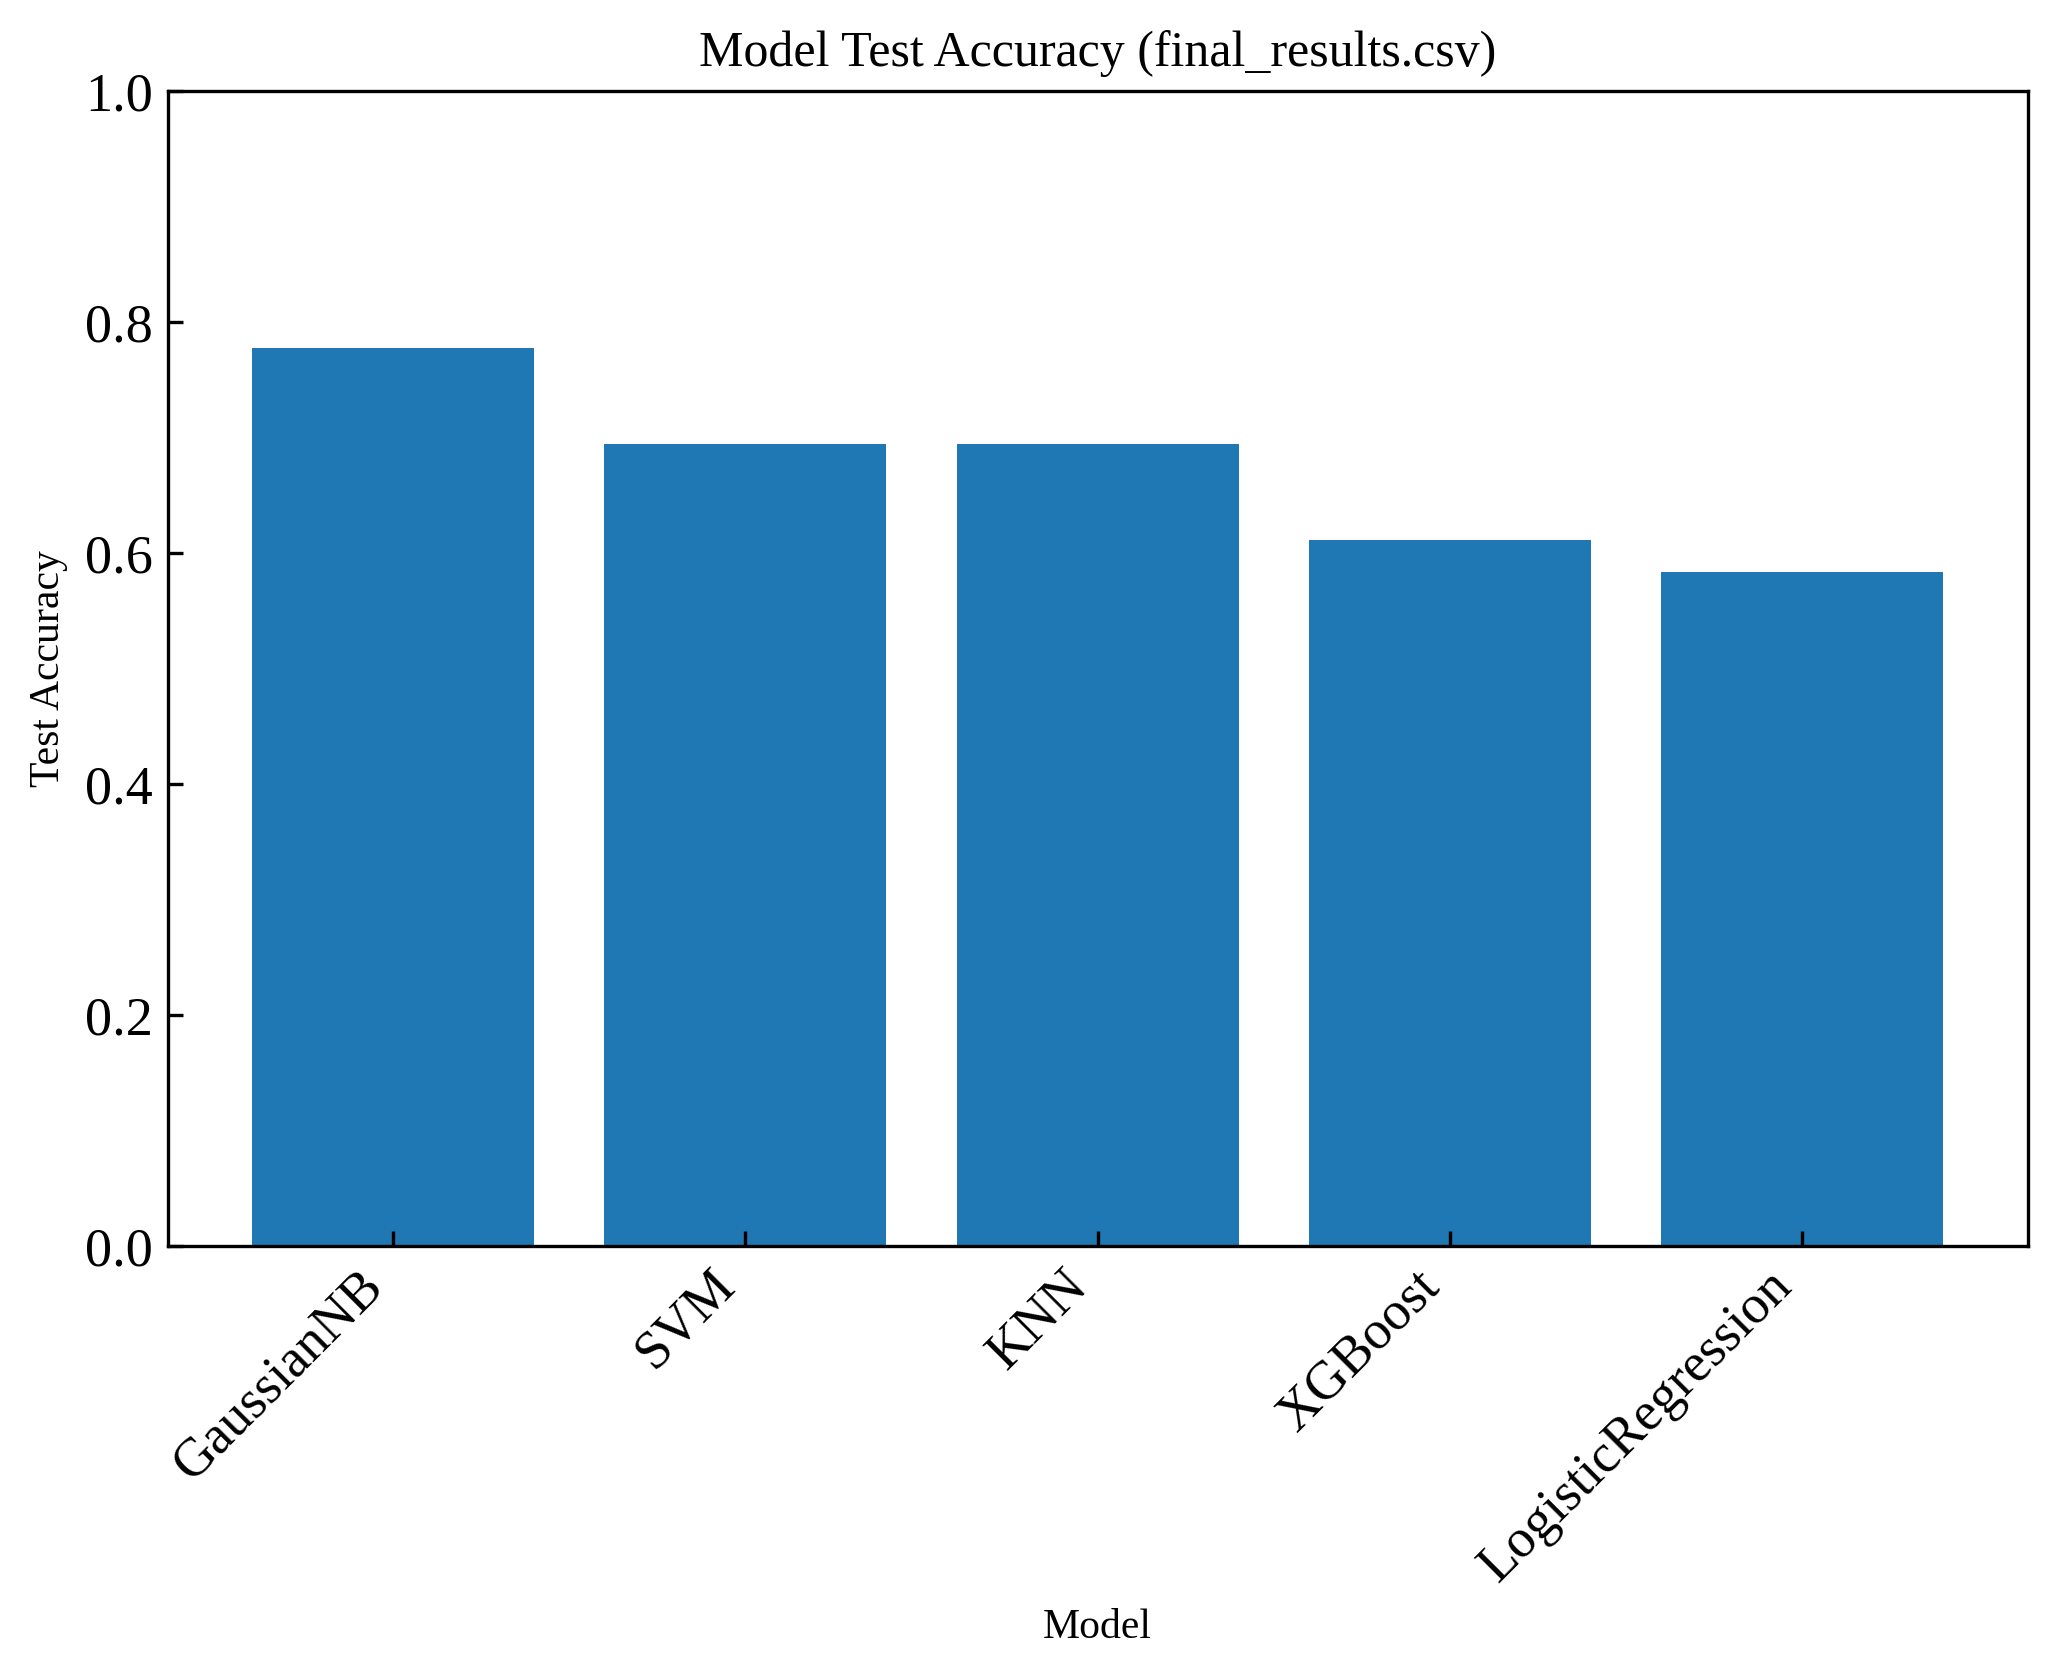

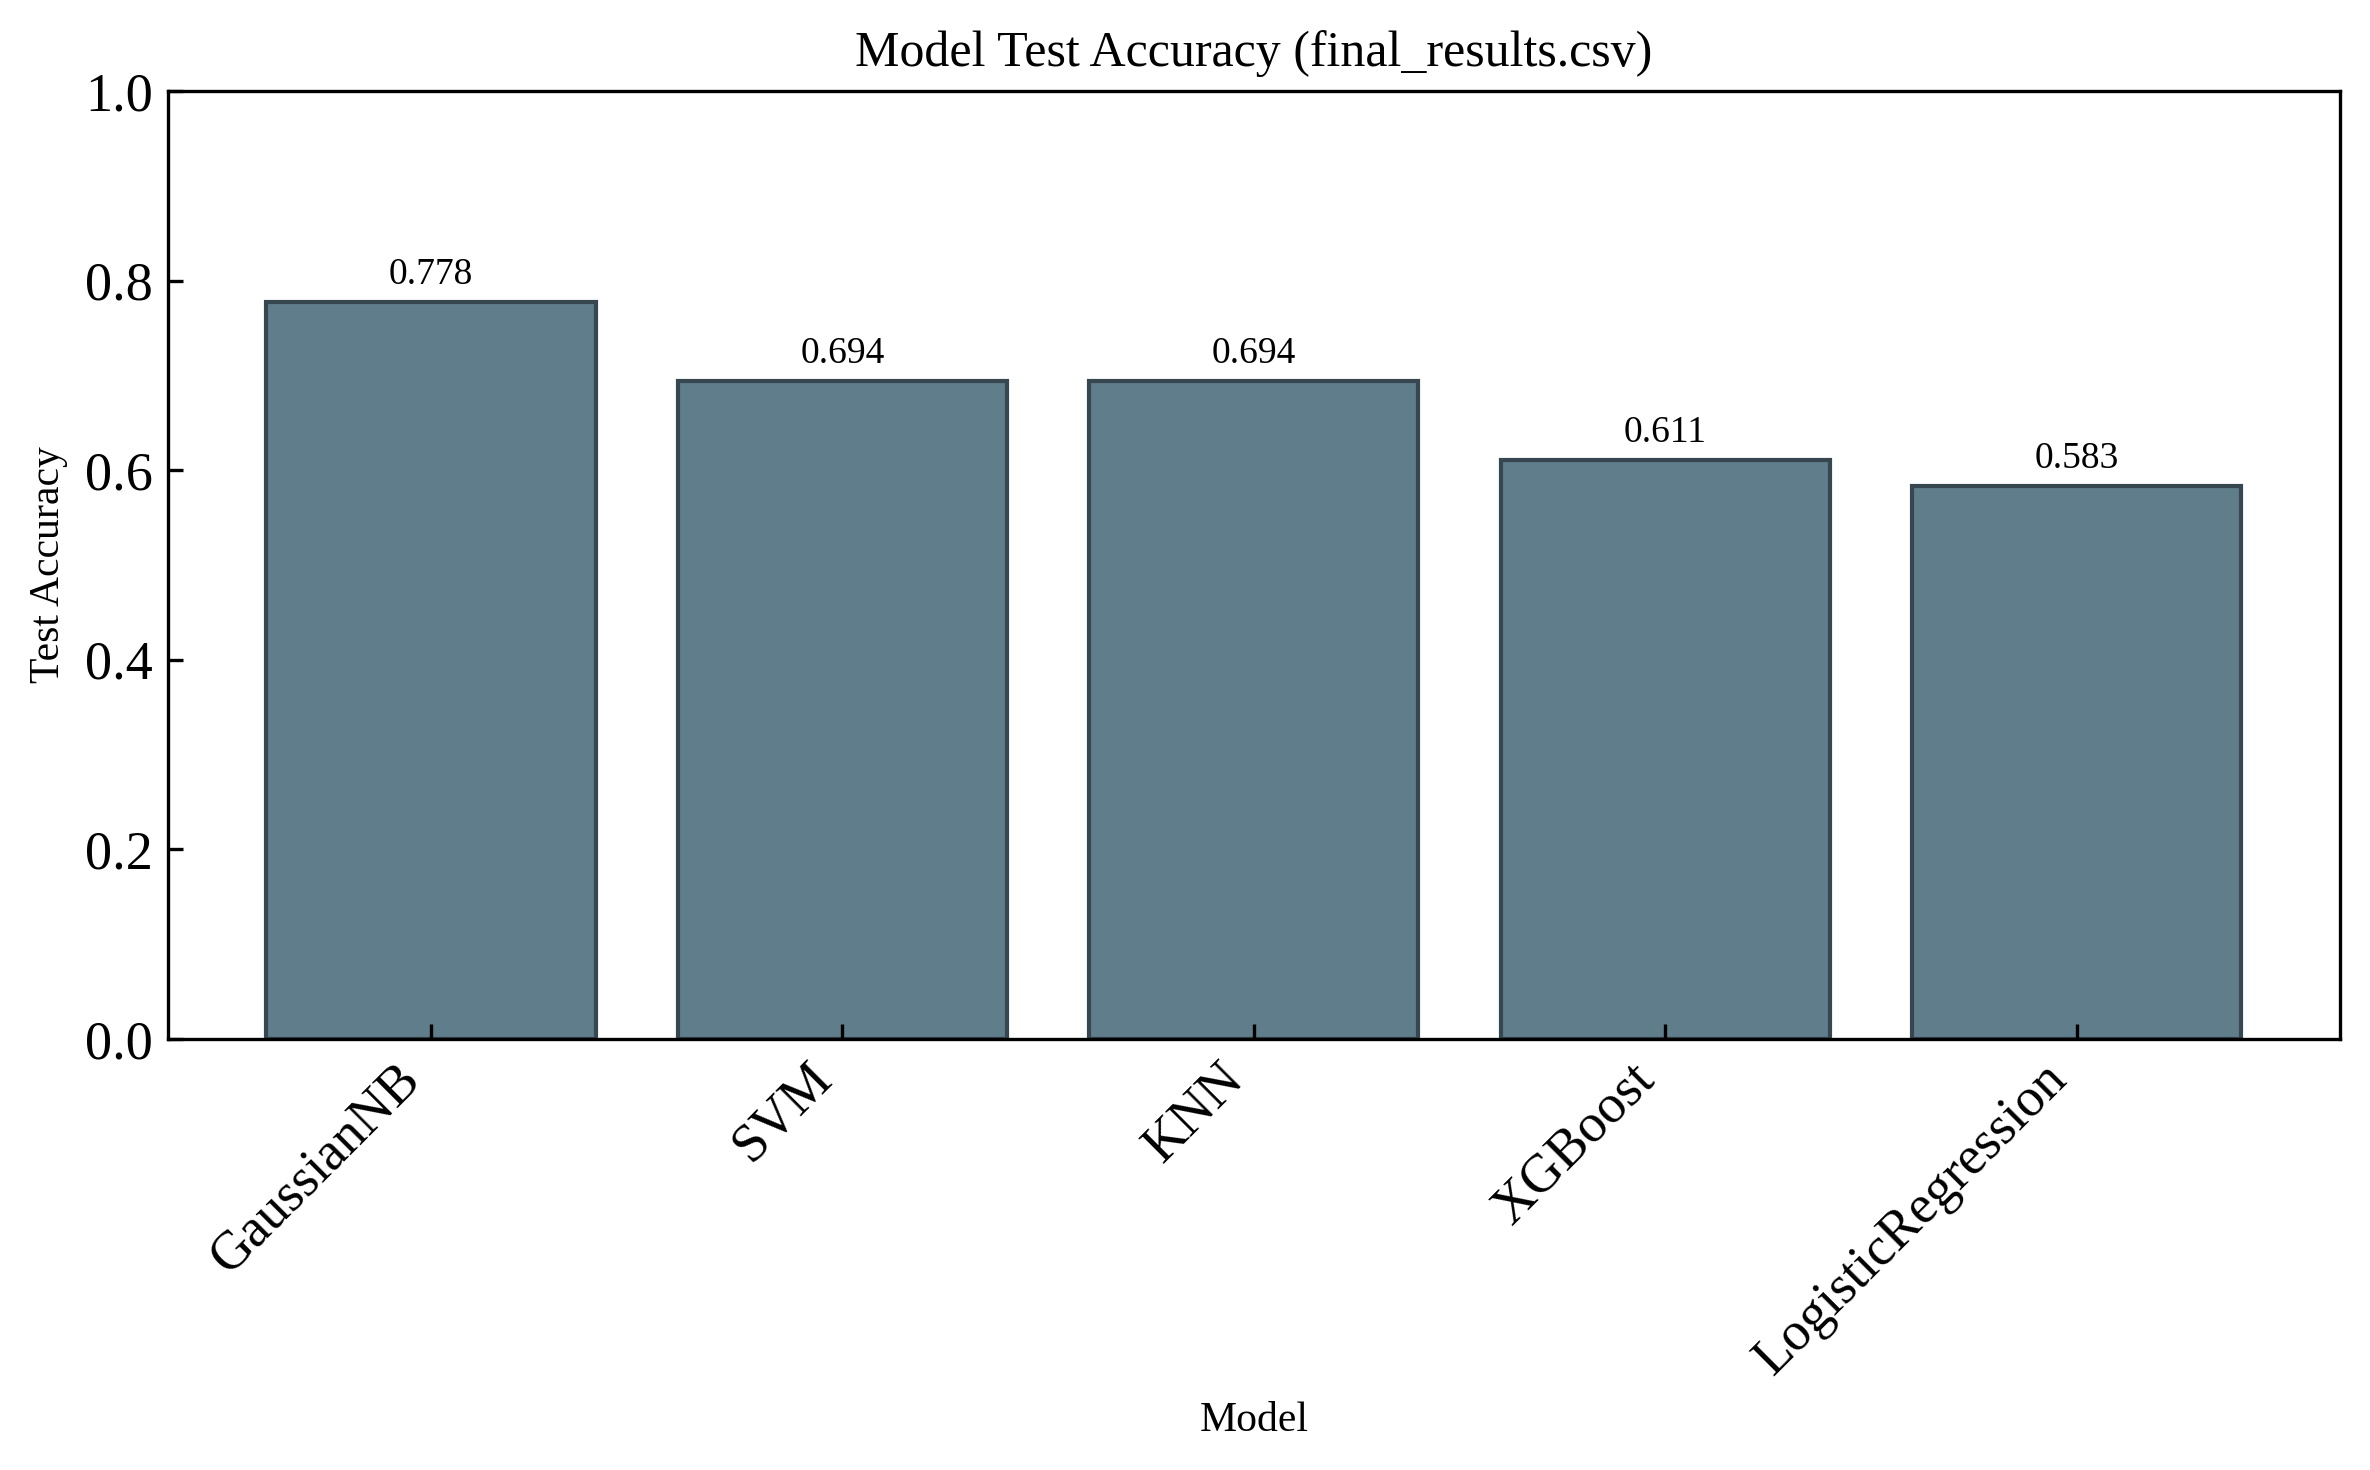


Best model: GaussianNB with test_acc= 0.7777777777777778


ValueError: '#004D40' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_

In [ ]:
from scipy import stats
import numpy as np
from statsmodels.stats.multitest import multipletests
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import warnings

warnings.filterwarnings('ignore', message='.*use_label_encoder.*')
from matplotlib.colors import ListedColormap

# Color palette (tweak as you like)
COLORS = {
    "bars": "#607D8B",          # blue-grey for barplot
    "bars_edge": "#37474F",
    "roc": "#D81B60",           # magenta for ROC curve
    "roc_diag": "#9E9E9E",      # grey diagonal
    "cm_light": "#E3F2FD",      # light blue
    "cm_dark": "#1565C0",       # dark blue
}

###############################################################################
# Matplotlib style
###############################################################################
def set_mpl_style(usetex: bool = False, interactive: bool = False) -> None:
    if not interactive:
        plt.ioff()  # disable interactive popups


    mpl.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.unicode_minus": False,
    })

    if usetex:
        # LaTeX mode – text is rendered by TeX, not by system TTF
        mpl.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times"],
            "text.latex.preamble": r"\usepackage{newtxtext,newtxmath}",
        })
    else:
        # Non-LaTeX: use Times if Matplotlib sees it, otherwise Liberation/DejaVu/STIX
        mpl.rcParams.update({
            "text.usetex": False,
            "font.family": "serif",
            "font.serif": [
                "Times New Roman",
                "Times",
                "Liberation Serif",
                "DejaVu Serif",
                "STIX Two Text",
            ],
            "mathtext.fontset": "stix",
        })

# apply plotting style globally
set_mpl_style(usetex=False, interactive=False)

###############################################################################
# Helpers for metric CIs
###############################################################################
BOOT_N = 2000
ALPHA = 0.05

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=BOOT_N, alpha=ALPHA, random_state=42):
    """Nonparametric bootstrap CI on test-set metric."""
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        scores.append(metric_func(y_true[idx], y_pred[idx]))
    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    return float(lower), float(upper)

def evaluate_on_test(y_true, y_pred):
    """Return point estimates + 95% CIs for accuracy, balanced acc, macro F1."""
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    acc_ci_low, acc_ci_high = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: accuracy_score(yt, yp)
    )
    bal_ci_low, bal_ci_high = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: balanced_accuracy_score(yt, yp)
    )
    f1_ci_low, f1_ci_high = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: f1_score(yt, yp, average='macro')
    )

    return {
        "test_acc": acc,
        "test_bal_acc": bal_acc,
        "test_f1_macro": f1_macro,
        "acc_ci_low": acc_ci_low,
        "acc_ci_high": acc_ci_high,
        "bal_acc_ci_low": bal_ci_low,
        "bal_acc_ci_high": bal_ci_high,
        "f1_ci_low": f1_ci_low,
        "f1_ci_high": f1_ci_high,
    }

###############################################################################
# Build raw feature matrix and labels
###############################################################################
# features is assumed to exist already
X_raw = features[[c for c in features.columns
                  if c not in {'Subject', 'Group', 'Center', 'FIQ', 'IQ'}]].copy()

# Build label series from 'Group' column
if 'Group' in features.columns:
    le = LabelEncoder()
    y_series = pd.Series(le.fit_transform(features['Group']), index=features.index)
    print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    raise NameError("Cannot build labels: 'Group' column missing in `features`.")

# Drop rows with missing values
mask = X_raw.notna().all(axis=1) & y_series.notna()
X_raw = X_raw[mask]
y = y_series[mask].values

print(f"Samples: {len(y)}")
print(f"Class distribution: {np.bincount(y)}\n")

# Train-test split BEFORE feature selection to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

###############################################################################
# Random Forest feature selection on TRAINING data only
###############################################################################
print("Performing Random Forest feature selection on training data...")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Get feature importances
importances = rf_selector.feature_importances_
feature_names = X_raw.columns.tolist()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Select top features (limit to prevent overfitting)
n_features_limit = max(10, int(len(feature_names) * 0.25))  # Use top 25% or minimum 10 features
top_features = feature_importance_df.head(n_features_limit)['Feature'].tolist()

print(f"\nRandom Forest Feature Importances (top {n_features_limit}):")
print(feature_importance_df.head(n_features_limit).to_string(index=False))

print(f"\nUsing {len(top_features)} features for machine learning classification")
print(f"Feature categories distribution:")
for cat in ['Whole', 'Intra', 'Inter']:
    cat_count = len([f for f in top_features if f.startswith(cat)])
    print(f"  {cat}: {cat_count} features")
print(f"\nSelected features: {top_features}\n")

# Prepare feature matrices using selected features only
X_train_selected = X_train[top_features].copy()
X_test_selected = X_test[top_features].copy()

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}
estimators = {}

###############################################################################
# SVM
###############################################################################
print("Training SVM...")
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, random_state=42, class_weight='balanced'))
])
param_svm = {
    'clf__C': [0.01, 0.1, 0.5, 1, 5, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
    'clf__kernel': ['rbf', 'poly']
}
grid_svm = GridSearchCV(pipe_svm, param_svm, cv=cv, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_selected, y_train)
best_svm = grid_svm.best_estimator_
estimators['SVM'] = best_svm

y_pred = best_svm.predict(X_test_selected)
y_proba = best_svm.predict_proba(X_test_selected)[:, 1]
metrics_svm = evaluate_on_test(y_test, y_pred)
results['SVM'] = {
    'best_params': grid_svm.best_params_,
    'cv_score': grid_svm.best_score_,
    **metrics_svm
}
print("SVM test accuracy:", metrics_svm['test_acc'])
print("SVM balanced accuracy:", metrics_svm['test_bal_acc'])
print("SVM F1 (macro):", metrics_svm['test_f1_macro'])
print("SVM 95% CI (acc): [{:.3f}, {:.3f}]".format(
    metrics_svm['acc_ci_low'], metrics_svm['acc_ci_high']
))
print("SVM 95% CI (bal acc): [{:.3f}, {:.3f}]".format(
    metrics_svm['bal_acc_ci_low'], metrics_svm['bal_acc_ci_high']
))
print("SVM 95% CI (F1 macro): [{:.3f}, {:.3f}]".format(
    metrics_svm['f1_ci_low'], metrics_svm['f1_ci_high']
))
print(classification_report(y_test, y_pred))

###############################################################################
# XGBoost
###############################################################################
print("Training XGBoost...")
pipe_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0,
        scale_pos_weight=1
    ))
])
param_xgb = {
    'clf__n_estimators': [50, 100, 200, 300],
    'clf__max_depth': [2, 3, 5, 7, 9],
    'clf__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.9, 1.0]
}
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_selected, y_train)
best_xgb = grid_xgb.best_estimator_
estimators['XGBoost'] = best_xgb

y_pred = best_xgb.predict(X_test_selected)
try:
    y_proba = best_xgb.predict_proba(X_test_selected)[:, 1]
except Exception:
    y_proba = None
metrics_xgb = evaluate_on_test(y_test, y_pred)
results['XGBoost'] = {
    'best_params': grid_xgb.best_params_,
    'cv_score': grid_xgb.best_score_,
    **metrics_xgb
}
print("XGBoost test accuracy:", metrics_xgb['test_acc'])
print("XGBoost balanced accuracy:", metrics_xgb['test_bal_acc'])
print("XGBoost F1 (macro):", metrics_xgb['test_f1_macro'])
print("XGBoost 95% CI (acc): [{:.3f}, {:.3f}]".format(
    metrics_xgb['acc_ci_low'], metrics_xgb['acc_ci_high']
))
print("XGBoost 95% CI (bal acc): [{:.3f}, {:.3f}]".format(
    metrics_xgb['bal_acc_ci_low'], metrics_xgb['bal_acc_ci_high']
))
print("XGBoost 95% CI (F1 macro): [{:.3f}, {:.3f}]".format(
    metrics_xgb['f1_ci_low'], metrics_xgb['f1_ci_high']
))
print(classification_report(y_test, y_pred))

###############################################################################
# Logistic Regression
###############################################################################
print("Training Logistic Regression...")
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        random_state=42,
        max_iter=100000,
        class_weight='balanced'
    ))
])
param_lr = {
    'clf__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear', 'saga']
}
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_selected, y_train)
best_lr = grid_lr.best_estimator_
estimators['LogisticRegression'] = best_lr

y_pred = best_lr.predict(X_test_selected)
y_proba = best_lr.predict_proba(X_test_selected)[:, 1]
metrics_lr = evaluate_on_test(y_test, y_pred)
results['LogisticRegression'] = {
    'best_params': grid_lr.best_params_,
    'cv_score': grid_lr.best_score_,
    **metrics_lr
}
print("Logistic Regression test accuracy:", metrics_lr['test_acc'])
print("Logistic Regression balanced accuracy:", metrics_lr['test_bal_acc'])
print("Logistic Regression F1 (macro):", metrics_lr['test_f1_macro'])
print("Logistic Regression 95% CI (acc): [{:.3f}, {:.3f}]".format(
    metrics_lr['acc_ci_low'], metrics_lr['acc_ci_high']
))
print("Logistic Regression 95% CI (bal acc): [{:.3f}, {:.3f}]".format(
    metrics_lr['bal_acc_ci_low'], metrics_lr['bal_acc_ci_high']
))
print("Logistic Regression 95% CI (F1 macro): [{:.3f}, {:.3f}]".format(
    metrics_lr['f1_ci_low'], metrics_lr['f1_ci_high']
))
print(classification_report(y_test, y_pred))

###############################################################################
# Naive Bayes
###############################################################################
print("Training Gaussian Naive Bayes...")
pipe_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GaussianNB())
])
param_nb = {'clf__var_smoothing': [1e-9, 1e-8, 1e-7]}
grid_nb = GridSearchCV(pipe_nb, param_nb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train_selected, y_train)
best_nb = grid_nb.best_estimator_
estimators['GaussianNB'] = best_nb

y_pred = best_nb.predict(X_test_selected)
y_proba = best_nb.predict_proba(X_test_selected)[:, 1]
metrics_nb = evaluate_on_test(y_test, y_pred)
results['GaussianNB'] = {
    'best_params': grid_nb.best_params_,
    'cv_score': grid_nb.best_score_,
    **metrics_nb
}
print("Naive Bayes test accuracy:", metrics_nb['test_acc'])
print("Naive Bayes balanced accuracy:", metrics_nb['test_bal_acc'])
print("Naive Bayes F1 (macro):", metrics_nb['test_f1_macro'])
print("Naive Bayes 95% CI (acc): [{:.3f}, {:.3f}]".format(
    metrics_nb['acc_ci_low'], metrics_nb['acc_ci_high']
))
print("Naive Bayes 95% CI (bal acc): [{:.3f}, {:.3f}]".format(
    metrics_nb['bal_acc_ci_low'], metrics_nb['bal_acc_ci_high']
))
print("Naive Bayes 95% CI (F1 macro): [{:.3f}, {:.3f}]".format(
    metrics_nb['f1_ci_low'], metrics_nb['f1_ci_high']
))
print(classification_report(y_test, y_pred))

###############################################################################
# KNN
###############################################################################
print("Training KNN...")
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])
param_knn = {
    'clf__n_neighbors': list(range(2, 40)),
    'clf__metric': ['euclidean']
}
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=cv, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_selected, y_train)
best_knn = grid_knn.best_estimator_
estimators['KNN'] = best_knn

y_pred = best_knn.predict(X_test_selected)
try:
    y_proba = best_knn.predict_proba(X_test_selected)[:, 1]
except Exception:
    y_proba = None
metrics_knn = evaluate_on_test(y_test, y_pred)
results['KNN'] = {
    'best_params': grid_knn.best_params_,
    'cv_score': grid_knn.best_score_,
    **metrics_knn
}
print("KNN test accuracy:", metrics_knn['test_acc'])
print("KNN balanced accuracy:", metrics_knn['test_bal_acc'])
print("KNN F1 (macro):", metrics_knn['test_f1_macro'])
print("KNN 95% CI (acc): [{:.3f}, {:.3f}]".format(
    metrics_knn['acc_ci_low'], metrics_knn['acc_ci_high']
))
print("KNN 95% CI (bal acc): [{:.3f}, {:.3f}]".format(
    metrics_knn['bal_acc_ci_low'], metrics_knn['bal_acc_ci_high']
))
print("KNN 95% CI (F1 macro): [{:.3f}, {:.3f}]".format(
    metrics_knn['f1_ci_low'], metrics_knn['f1_ci_high']
))
print(classification_report(y_test, y_pred))

###############################################################################
# Summary of results: save to CSV
###############################################################################
rows = []
for name, metrics in results.items():
    row = {'model': name}
    row.update(metrics)
    # encode best_params as JSON
    row['best_params'] = json.dumps(metrics['best_params'])
    rows.append(row)

results_df = pd.DataFrame(rows)
out_base = '/home/saeedrafshar/Desktop/pre_sub_tests/LATEST'
results_path = f'{out_base}/final_results.csv'
results_df.to_csv(results_path, index=False)
print(f"\nSaved results to {results_path}")

###############################################################################
# Bar plot of test accuracy for all models (with style applied)
###############################################################################
try:
    plot_df = pd.read_csv(results_path)
except Exception:
    plot_df = results_df.copy()

plot_df['test_acc'] = pd.to_numeric(plot_df['test_acc'], errors='coerce')
plot_df = plot_df.sort_values('test_acc', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
models = plot_df['model'].astype(str).tolist()
accs = plot_df['test_acc'].tolist()

bars = ax.bar(
    models,
    accs,
    color=COLORS["bars"],
    edgecolor=COLORS["bars_edge"]
)

ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Test Accuracy (final_results.csv)')
ax.set_xlabel('Model')
plt.xticks(rotation=45, ha='right')

for bar, acc in zip(bars, accs):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f"{acc:.3f}",
            ha='center',
            va='bottom',
            fontsize=9)

plt.tight_layout()
barplot_path = f'{out_base}/final_results_barplot.pdf'
plt.savefig(barplot_path, dpi=300)
print(f"Saved final results barplot to {barplot_path}")
plt.show()

###############################################################################
# Identify best model by test accuracy
###############################################################################
best_model_name = max(results.items(), key=lambda kv: kv[1]['test_acc'])[0]
best_model = estimators[best_model_name]
print("\nBest model:", best_model_name, "with test_acc=",
      results[best_model_name]['test_acc'])

###############################################################################
# Plot confusion matrix and ROC/AUC for best model (with style)
###############################################################################
y_best_pred = best_model.predict(X_test_selected)
y_best_proba = None
try:
    y_best_proba = best_model.predict_proba(X_test_selected)[:, 1]
except Exception:
    try:
        y_best_proba = best_model.decision_function(X_test_selected)
    except Exception:
        y_best_proba = None

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_best_pred,
    display_labels=['ASD', 'Control'],
    cmap='cm_dark',
    colorbar=False,
    ax=axs[0]
)
axs[0].set_title(f'Confusion Matrix ({best_model_name})')

if y_best_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_best_proba)
    roc_auc = auc(fpr, tpr)
    axs[1].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axs[1].plot([0, 1], [0, 1], lw=2, linestyle='--')
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive Rate')
    axs[1].set_title(f'ROC Curve ({best_model_name})')
    axs[1].legend(loc="lower right")
    axs[1].grid(True)
else:
    axs[1].text(
        0.5, 0.5,
        'Probabilities not available',
        horizontalalignment='center',
        verticalalignment='center'
    )
    axs[1].set_axis_off()

plt.tight_layout()
fig_name = f'{out_base}/best_model_{best_model_name}_confusion_auc.pdf'
plt.savefig(fig_name, dpi=300)
print("Saved best-model confusion/AUC figure to", fig_name)
plt.show()

###############################################################################
# Save test predictions
###############################################################################
preds_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_best_pred})
if y_best_proba is not None:
    preds_df['y_proba'] = y_best_proba
preds_path = f'{out_base}/best_model_test_predictions.csv'
preds_df.to_csv(preds_path, index=False)
print("Saved test predictions to", preds_path)

###############################################################################
# Save feature importance summary
###############################################################################
feat_imp_path = f'{out_base}/random_forest_feature_importance.csv'
feature_importance_df.to_csv(feat_imp_path, index=False)
print("Saved Random Forest feature importances to", feat_imp_path)


ML PIPELINE WITH COMBATS BATCH EFFECT CORRECTION

Label encoding: {'ASD': np.int64(0), 'Control': np.int64(1)}
Samples: 182
Class distribution: [90 92]

STEP 1: ComBat Batch Effect Correction
Data shape for ComBat (features x samples): (91, 182)
Covariates shape: (182, 1)
Biological variable preserved: Group (ASD vs Control)

Applying ComBat harmonization...
⚠ ComBat harmonization failed: index 0 is out of bounds for axis 0 with size 0
Proceeding with original data...

STEP 2: Train-Test Split and Feature Selection (on harmonized data)
Training set: 145 samples
Test set: 37 samples

Performing Random Forest feature selection on training data (post-ComBat)...

Random Forest Feature Importances (top 22):
                                            Feature  Importance
                Inter_Visual__SomatoMotor_AvgWeight    0.034230
                               Whole_Prop_agreement    0.030923
                         Whole_Prop_imbalanced_same    0.029116
                Inter_SomatoMoto

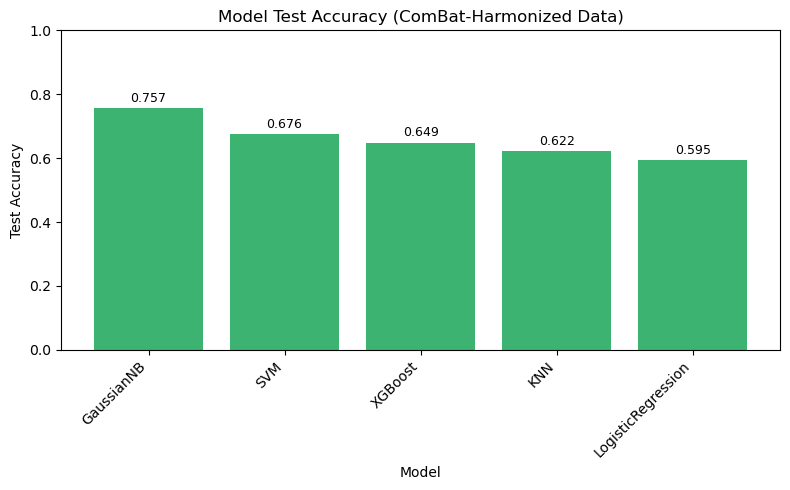


Best model: GaussianNB with test_acc= 0.7567567567567568
Saved best-model confusion/AUC figure to /home/saeedrafshar/Desktop/pre_sub_tests/LATEST/best_model_GaussianNB_confusion_auc_combat.png


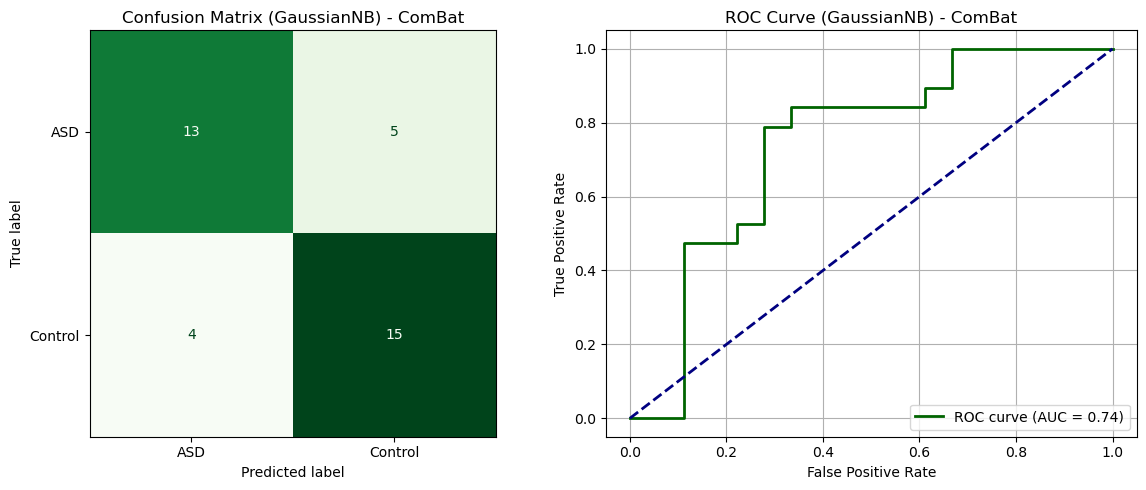

Saved test predictions to best_model_test_predictions_combat.csv
Saved Random Forest feature importances to random_forest_feature_importance_combat.csv

ComBat-Harmonized ML Pipeline Complete!


In [ ]:
from scipy import stats
import numpy as np
from statsmodels.stats.multitest import multipletests
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
from neuroCombat import neuroCombat

warnings.filterwarnings('ignore', message='.*use_label_encoder.*')

print("=" * 100)
print("ML PIPELINE WITH COMBATS BATCH EFFECT CORRECTION")
print("=" * 100)

# Build raw feature matrix and labels
X_raw = features[[c for c in features.columns if c not in {'Subject', 'Group'}]].copy()

# Build label series from 'Group' column
if 'Group' in features.columns:
    le = LabelEncoder()
    y_series = pd.Series(le.fit_transform(features['Group']), index=features.index)
    print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    raise NameError("Cannot build labels: 'Group' column missing in `features`.")

# Drop rows with missing values
mask = X_raw.notna().all(axis=1) & y_series.notna()
X_raw = X_raw[mask]
y = y_series[mask].values

print(f"Samples: {len(y)}")
print(f"Class distribution: {np.bincount(y)}\n")

# STEP 1: Apply ComBat for batch effect harmonization
print("=" * 100)
print("STEP 1: ComBat Batch Effect Correction")
print("=" * 100)

# ComBat expects data in format: samples x features
# Create metadata dataframe required by ComBat
combat_data = X_raw.T  # Transpose to features x samples format
print(f"Data shape for ComBat (features x samples): {combat_data.shape}")

# Create covariates dataframe for ComBat
# Assuming we want to preserve biological signal (Group) while removing batch effects
# If you have batch information, add it here; otherwise ComBat will estimate batch effects from variance patterns
covars = pd.DataFrame({
    'Group': y
}, index=X_raw.index)

print(f"Covariates shape: {covars.shape}")
print(f"Biological variable preserved: Group (ASD vs Control)")

# Apply ComBat harmonization
# data: samples x features (will be transposed internally or as needed)
# covars: sample metadata with biological variables
# batch_col: if you have explicit batch labels; if None, ComBat estimates harmonization
try:
    print("\nApplying ComBat harmonization...")
    # Prepare data for ComBat (features x samples)
    combat_data_harmonized = neuroCombat(
        dat=combat_data,
        covars=covars,
        batch_col=None  # Set to column name if explicit batch info available
    )
    X_raw_harmonized = combat_data_harmonized['data'].T  # Transpose back to samples x features
    print("✓ ComBat harmonization completed successfully")
    print(f"Harmonized data shape: {X_raw_harmonized.shape}")
except Exception as e:
    print(f"⚠ ComBat harmonization failed: {e}")
    print("Proceeding with original data...")
    X_raw_harmonized = X_raw.copy()

# Convert harmonized data back to DataFrame with original column names
X_raw_harmonized = pd.DataFrame(X_raw_harmonized, columns=X_raw.columns, index=X_raw.index)

print("\n" + "=" * 100)
print("STEP 2: Train-Test Split and Feature Selection (on harmonized data)")
print("=" * 100)

# Train-test split BEFORE feature selection to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_raw_harmonized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Random Forest feature selection on TRAINING data only
print("\nPerforming Random Forest feature selection on training data (post-ComBat)...")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Get feature importances
importances = rf_selector.feature_importances_
feature_names = X_raw_harmonized.columns.tolist()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Select top features (limit to prevent overfitting)
n_features_limit = max(10, int(len(feature_names) * 0.25))  # Use top 25% or minimum 10 features
top_features = feature_importance_df.head(n_features_limit)['Feature'].tolist()

print(f"\nRandom Forest Feature Importances (top {n_features_limit}):")
print(feature_importance_df.head(n_features_limit).to_string(index=False))

print(f"\nUsing {len(top_features)} features for machine learning classification")
print(f"Feature categories distribution:")
for cat in ['Whole', 'Intra', 'Inter']:
    cat_count = len([f for f in top_features if f.startswith(cat)])
    print(f"  {cat}: {cat_count} features")
print(f"\nSelected features: {top_features}\n")

# Prepare feature matrices using selected features only
X_train_selected = X_train[top_features].copy()
X_test_selected = X_test[top_features].copy()

print("=" * 100)
print("STEP 3: Hyperparameter Optimization with GridSearchCV + StratifiedKFold")
print("=" * 100)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}
estimators = {}

# SVM: pipeline with scaler; gridsearch on TRAIN only
print("\nTraining SVM...")
pipe_svm = Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=42, class_weight='balanced'))])
param_svm = {'clf__C': [0.01, 0.1, 0.5, 1, 5, 10, 100], 'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01], 'clf__kernel': ['rbf', 'poly']}
grid_svm = GridSearchCV(pipe_svm, param_svm, cv=cv, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_selected, y_train)
best_svm = grid_svm.best_estimator_
estimators['SVM'] = best_svm
y_pred = best_svm.predict(X_test_selected)
y_proba = best_svm.predict_proba(X_test_selected)[:, 1]
results['SVM'] = {'best_params': grid_svm.best_params_, 'cv_score': grid_svm.best_score_, 'test_acc': accuracy_score(y_test, y_pred)}
print("SVM test accuracy:", results['SVM']['test_acc'])
print(classification_report(y_test, y_pred))

# XGBoost
print("Training XGBoost...")
pipe_xgb = Pipeline([("scaler", StandardScaler()), ("clf", XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0, scale_pos_weight=1))])
param_xgb = {'clf__n_estimators': [50, 100, 200, 300], 'clf__max_depth': [2, 3, 5, 7, 9], 'clf__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2], 'clf__subsample': [0.7, 0.9, 1.0], 'clf__colsample_bytree': [0.7, 0.9, 1.0]}
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_selected, y_train)
best_xgb = grid_xgb.best_estimator_
estimators['XGBoost'] = best_xgb
y_pred = best_xgb.predict(X_test_selected)
try:
    y_proba = best_xgb.predict_proba(X_test_selected)[:, 1]
except Exception:
    y_proba = None
results['XGBoost'] = {'best_params': grid_xgb.best_params_, 'cv_score': grid_xgb.best_score_, 'test_acc': accuracy_score(y_test, y_pred)}
print("XGBoost test accuracy:", results['XGBoost']['test_acc'])
print(classification_report(y_test, y_pred))

# Logistic Regression
print("Training Logistic Regression...")
pipe_lr = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=42, max_iter=100000, class_weight='balanced'))])
param_lr = {'clf__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear', 'saga']}
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_selected, y_train)
best_lr = grid_lr.best_estimator_
estimators['LogisticRegression'] = best_lr
y_pred = best_lr.predict(X_test_selected)
y_proba = best_lr.predict_proba(X_test_selected)[:, 1]
results['LogisticRegression'] = {'best_params': grid_lr.best_params_, 'cv_score': grid_lr.best_score_, 'test_acc': accuracy_score(y_test, y_pred)}
print("Logistic Regression test accuracy:", results['LogisticRegression']['test_acc'])
print(classification_report(y_test, y_pred))

# Naive Bayes
print("Training Gaussian Naive Bayes...")
pipe_nb = Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())])
param_nb = {'clf__var_smoothing': [1e-9, 1e-8, 1e-7]}
grid_nb = GridSearchCV(pipe_nb, param_nb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_nb.fit(X_train_selected, y_train)
best_nb = grid_nb.best_estimator_
estimators['GaussianNB'] = best_nb
y_pred = best_nb.predict(X_test_selected)
y_proba = best_nb.predict_proba(X_test_selected)[:, 1]
results['GaussianNB'] = {'best_params': grid_nb.best_params_, 'cv_score': grid_nb.best_score_, 'test_acc': accuracy_score(y_test, y_pred)}
print("Naive Bayes test accuracy:", results['GaussianNB']['test_acc'])
print(classification_report(y_test, y_pred))

# KNN
print("Training KNN...")
pipe_knn = Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())])
param_knn = {'clf__n_neighbors': list(range(2, 40)), 'clf__metric': ['euclidean']}
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=cv, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_selected, y_train)
best_knn = grid_knn.best_estimator_
estimators['KNN'] = best_knn
y_pred = best_knn.predict(X_test_selected)
try:
    y_proba = best_knn.predict_proba(X_test_selected)[:, 1]
except Exception:
    y_proba = None
results['KNN'] = {'best_params': grid_knn.best_params_, 'cv_score': grid_knn.best_score_, 'test_acc': accuracy_score(y_test, y_pred)}
print("KNN test accuracy:", results['KNN']['test_acc'])
print(classification_report(y_test, y_pred))

print("\n" + "=" * 100)
print("STEP 4: Results Summary and Visualization")
print("=" * 100)

# Summary of results: save to CSV
results_df = pd.DataFrame([
    {'model': name, 'best_params': json.dumps(results[name]['best_params']), 'cv_score': results[name]['cv_score'], 'test_acc': results[name]['test_acc']}
    for name in results
])
results_df.to_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/final_results_combat.csv', index=False)
print("\nSaved results to final_results_combat.csv")

# Bar plot of test_acc for all models
try:
    plot_df = pd.read_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/final_results_combat.csv')
except Exception:
    plot_df = results_df.copy()

plot_df['test_acc'] = pd.to_numeric(plot_df['test_acc'], errors='coerce')
plot_df = plot_df.sort_values('test_acc', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
models = plot_df['model'].astype(str).tolist()
accs = plot_df['test_acc'].tolist()

bars = ax.bar(
    models,
    accs,
    color=COLORS["bars"],
    edgecolor=COLORS["bars_edge"]
)

ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Test Accuracy (ComBat-Harmonized Data)')
ax.set_xlabel('Model')
plt.xticks(rotation=45, ha='right')

for bar, acc in zip(bars, accs):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{acc:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/final_results_barplot_combat.png', dpi=300)
print("Saved final results barplot to final_results_barplot_combat.png")
plt.show()

# Identify best model by test accuracy
best_model_name = max(results.items(), key=lambda kv: kv[1]['test_acc'])[0]
best_model = estimators[best_model_name]
print("\nBest model:", best_model_name, "with test_acc=", results[best_model_name]['test_acc'])

# Plot confusion matrix and ROC/AUC for best model
y_best_pred = best_model.predict(X_test_selected)
y_best_proba = None
try:
    y_best_proba = best_model.predict_proba(X_test_selected)[:, 1]
except Exception:
    try:
        y_best_proba = best_model.decision_function(X_test_selected)
    except Exception:
        y_best_proba = None

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Custom colormap for confusion matrix
cm_cmap = ListedColormap([COLORS["cm_light"], COLORS["cm_dark"]])

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_best_pred,
    display_labels=['ASD', 'Control'],
    cmap=cm_cmap,
    colorbar=False,
    ax=axs[0]
)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Custom colormap for confusion matrix
cm_cmap = ListedColormap([COLORS["cm_light"], COLORS["cm_dark"]])

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_best_pred,
    display_labels=['ASD', 'Control'],
    cmap=cm_cmap,
    colorbar=False,
    ax=axs[0]
)
axs[0].set_title(f'Confusion Matrix ({best_model_name})')

if y_best_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_best_proba)
    roc_auc = auc(fpr, tpr)

    axs[1].plot(
        fpr, tpr,
        lw=2,
        color=COLORS["roc"],
        label=f'ROC curve (AUC = {roc_auc:.2f})'
    )
    axs[1].plot(
        [0, 1], [0, 1],
        lw=2,
        linestyle='--',
        color=COLORS["roc_diag"]
    )
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive Rate')
    axs[1].set_title(f'ROC Curve ({best_model_name})')
    axs[1].legend(loc="lower right")
    axs[1].grid(True)
else:
    axs[1].text(
        0.5, 0.5,
        'Probabilities not available',
        horizontalalignment='center',
        verticalalignment='center'
    )
    axs[1].set_axis_off()


plt.tight_layout()
fig_name = f'/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/best_model_{best_model_name}_confusion_auc_combat.png'
plt.savefig(fig_name, dpi=300)
print("Saved best-model confusion/AUC figure to", fig_name)
plt.show()

# Save test predictions
preds_df = pd.DataFrame({'y_true': y_test, 'y_pred': y_best_pred})
if y_best_proba is not None:
    preds_df['y_proba'] = y_best_proba
preds_df.to_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/best_model_test_predictions_combat.csv', index=False)
print("Saved test predictions to best_model_test_predictions_combat.csv")

# Save feature importance summary
feature_importance_df.to_csv('/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/random_forest_feature_importance_combat.csv', index=False)
print("Saved Random Forest feature importances to random_forest_feature_importance_combat.csv")

print("\n" + "=" * 100)
print("ComBat-Harmonized ML Pipeline Complete!")
print("=" * 100)

In [6]:
#!/usr/bin/env python
import pandas as pd
import numpy as np

# ====== CONFIG: set your file names here ======
FEATURES_CSV   = "net_cbt_all_features_3levels.csv"   # your net_cbt_all file
PHENOTYPIC_CSV = "Phenotypic_V1_0b.csv"               # ABIDE phenotypic file
OUT_CSV        = "net_cbt_all_features_3levels_with_center_iq.csv"
# =============================================


def add_center_and_iq(features_csv, phenotypic_csv, out_csv):
    # Load data
    features = pd.read_csv(features_csv)
    phen = pd.read_csv(phenotypic_csv)

    # Basic checks
    if "Subject" not in features.columns:
        raise ValueError("Features file must contain a 'Subject' column.")
    for col in ["SUB_ID", "SITE_ID", "FIQ"]:
        if col not in phen.columns:
            raise ValueError(f"Phenotypic file must contain '{col}' column.")

    # Clean FIQ: ABIDE uses -9999 as missing; treat those as NaN
    phen = phen.copy()
    phen["FIQ"] = phen["FIQ"].replace(-9999, np.nan)

    # Compute mean IQ over valid FIQ values
    mean_fiq = phen["FIQ"].dropna().mean()

    # Prepare phenotypic subset for merging
    phen_sub = phen[["SUB_ID", "SITE_ID", "FIQ"]].copy()
    phen_sub = phen_sub.rename(columns={"SUB_ID": "Subject"})

    # Merge on subject ID
    merged = features.merge(phen_sub, on="Subject", how="left")

    # Create Center column from SITE_ID
    merged = merged.rename(columns={"SITE_ID": "Center"})

    # Create IQ column:
    #   - if FIQ is present, use it
    #   - otherwise use mean FIQ
    merged["IQ"] = merged["FIQ"].fillna(mean_fiq)

    # If you don't want the raw FIQ column afterward, uncomment:
    # merged = merged.drop(columns=["FIQ"])

    # Save result
    merged.to_csv(out_csv, index=False)

    # Simple summary printout
    n_missing_center = merged["Center"].isna().sum()
    n_missing_fiq = merged["FIQ"].isna().sum()

    print(f"Saved merged file to: {out_csv}")
    print(f"Mean IQ used for missing values: {mean_fiq:.3f}")
    print(f"Rows with missing Center: {n_missing_center}")
    print(f"Rows with missing raw FIQ (before filling IQ): {n_missing_fiq}")


if __name__ == "__main__":
    add_center_and_iq(FEATURES_CSV, PHENOTYPIC_CSV, OUT_CSV)


Saved merged file to: net_cbt_all_features_3levels_with_center_iq.csv
Mean IQ used for missing values: 108.381
Rows with missing Center: 0
Rows with missing raw FIQ (before filling IQ): 8


In [9]:
import pandas as pd
features = pd.read_csv('/home/saeedrafshar/Desktop/pre_sub_tests/net_cbt_all_features_3levels_with_center_iq.csv')


In [10]:
features

,Subject,Group,Whole_Energy_global,Whole_Prop_agreement,Whole_Prop_disagreement,Whole_Prop_imbalanced_same,Whole_Prop_imbalanced_opp,Whole_Bipolarity,Whole_Assortativity,Intra_Visual_AvgWeight,...,Inter_Limbic__Frontoparietal_EnergyBlock,Inter_Limbic__Default_AvgWeight,Inter_Limbic__Default_AvgFalffW,Inter_Limbic__Default_EnergyBlock,Inter_Frontoparietal__Default_AvgWeight,Inter_Frontoparietal__Default_AvgFalffW,Inter_Frontoparietal__Default_EnergyBlock,Center,FIQ,IQ
0,50499,ASD,-253.702620,0.251256,0.268442,0.246231,0.234070,0.628693,-0.005025,0.073691,...,-5.528254,0.159463,-0.026300,12.229613,0.094970,0.038460,-27.421896,USM,113.0,113.0
1,50694,ASD,-335.374892,0.251910,0.272362,0.245578,0.230151,0.617889,-0.005025,0.082095,...,-14.904955,0.148453,-0.009195,4.275841,0.242956,0.025350,-18.074474,LEUVEN_1,109.0,109.0
2,51020,ASD,-110.489855,0.238241,0.269447,0.259246,0.233065,0.628291,-0.005025,0.056042,...,7.141707,0.059896,0.012651,-5.882893,0.076540,0.010319,-7.357126,NYU,107.0,107.0
3,51470,ASD,-299.384270,0.249987,0.271408,0.247500,0.231105,0.481397,-0.005025,0.106502,...,3.926373,-0.016194,-0.004523,2.103274,0.097679,0.011036,-7.869007,CALTECH,124.0,124.0
4,50518,ASD,-281.227253,0.256583,0.270603,0.240905,0.231910,0.615477,-0.005025,0.079001,...,-10.042672,0.056838,0.008285,-3.852442,0.009112,0.028559,-20.362796,USM,77.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,50467,Control,-257.412804,0.247136,0.269698,0.250352,0.232814,0.618894,-0.005025,0.087884,...,-6.991534,0.033949,0.055333,-25.730006,-0.000818,-0.003769,2.687059,USM,89.0,89.0
178,50433,Control,-177.175944,0.251558,0.261960,0.245930,0.240553,0.628593,-0.005025,0.100400,...,-0.466298,0.177051,-0.019869,9.239130,-0.028654,0.015272,-10.888877,USM,100.0,100.0
179,50463,Control,-130.650896,0.247940,0.258744,0.249548,0.243769,0.649899,-0.005025,0.106298,...,3.531091,0.110751,-0.030464,14.165887,0.059672,0.025523,-18.198068,USM,121.0,121.0
180,51342,Control,-160.126558,0.247739,0.264422,0.249749,0.238090,0.632161,-0.005025,0.073945,...,-0.516529,0.141566,0.009508,-4.421177,-0.046793,0.015146,-10.798801,MAX_MUN,107.0,107.0


In [3]:
#!/usr/bin/env python
"""
Per-feature ComBat harmonization for your feature CSV.

- Input CSV columns:
    Subject, Group, Center, FIQ, IQ, <feature columns...>

- Output CSV:
    Same meta columns (Subject, Group, Center, FIQ, IQ),
    plus only those feature columns that successfully harmonized.
"""

import numpy as np
import pandas as pd
from neuroHarmonize import harmonizationLearn

# ----------------------------
# EDIT THESE PATHS
# ----------------------------
INPUT_CSV  = "/home/saeedrafshar/Desktop/pre_sub_tests/net_cbt_all_features_3levels_with_center_iq.csv"
OUTPUT_CSV = "/home/saeedrafshar/Desktop/pre_sub_tests/LATEST/features_ComBat_per_feature.csv"

# Non-feature columns (kept as-is)
NON_FEATURE_COLS = ["Subject", "Group", "Center", "FIQ", "IQ"]


def main():
    # 1) Load
    df = pd.read_csv(INPUT_CSV)
    print(f"[INFO] Loaded {INPUT_CSV}, shape = {df.shape}")

    for col in NON_FEATURE_COLS:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in CSV.")

    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
    print(f"[INFO] Number of feature columns: {len(feature_cols)}")

    # 2) Covariates for ComBat: SITE + numeric covariates
    covars = pd.DataFrame(index=df.index)
    covars["SITE"] = df["Center"].astype(str)

    # encode Group
    gmap = {"ASD": 1, "Control": 0}
    covars["Group_num"] = df["Group"].map(gmap)
    covars["FIQ"] = pd.to_numeric(df["FIQ"], errors="coerce")
    covars["IQ"]  = pd.to_numeric(df["IQ"],  errors="coerce")

    # impute covariate NaNs with median
    for col in ["Group_num", "FIQ", "IQ"]:
        if covars[col].isna().any():
            med = covars[col].median()
            print(f"[INFO] Imputing {covars[col].isna().sum()} NaNs in {col} with median={med:.3f}")
            covars[col] = covars[col].fillna(med)

    if covars.isna().any().any():
        raise RuntimeError("Covariates still contain NaNs after imputation.")

    covars_for_combat = covars[["SITE", "Group_num", "FIQ", "IQ"]]

    # 3) Per-feature ComBat
    harmonized = df[NON_FEATURE_COLS].copy()
    kept_features = []
    dropped_features = []

    for col in feature_cols:
        x = pd.to_numeric(df[col], errors="coerce")

        # Drop constant / all-NaN features
        n_unique = x.dropna().nunique()
        if n_unique <= 1:
            dropped_features.append((col, "constant or all-NaN"))
            continue

        # Impute feature NaNs with median
        if x.isna().any():
            med = x.median()
            x = x.fillna(med)

        data_mat = x.to_numpy().reshape(-1, 1)

        try:
            model, adj = harmonizationLearn(data_mat, covars_for_combat)
        except Exception as e:
            dropped_features.append((col, f"error: {type(e).__name__}"))
            continue

        adj_vec = adj[:, 0]
        if np.isnan(adj_vec).all():
            dropped_features.append((col, "ComBat returned all NaN"))
            continue

        harmonized[col] = adj_vec
        kept_features.append(col)

    print(f"[INFO] Kept features: {len(kept_features)}")
    print(f"[INFO] Dropped features: {len(dropped_features)}")

    if dropped_features:
        print("[INFO] Dropped feature reasons (first 20):")
        for name, reason in dropped_features[:20]:
            print(f"   {name}: {reason}")

    # 4) Save
    harmonized.to_csv(OUTPUT_CSV, index=False)
    print(f"[INFO] Harmonized CSV saved to: {OUTPUT_CSV}")


if __name__ == "__main__":
    main()


[INFO] Loaded /home/saeedrafshar/Desktop/pre_sub_tests/net_cbt_all_features_3levels_with_center_iq.csv, shape = (182, 96)
[INFO] Number of feature columns: 91
[INFO] Imputing 8 NaNs in FIQ with median=112.000

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one vari

/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dty


[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHar

/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dty


[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHar

/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dty


[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHarmonize]: Bypassing empirical Bayes step because only one variable to harmonize.

[neuroHar

/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/saeedrafshar/miniconda3/envs/ca_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dty